In [1]:
import pandas as pd
from aquarel import load_theme
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import scipy.stats as stats

FE_DF_PATH = Path("../data/processed/openaq_feature_engineered.parquet")
fe_df = pd.read_parquet(FE_DF_PATH)

In [2]:
# look at the df
fe_df.head()

,Country Code,City,Location,Pollutant,Source Name,Unit,Country Label,Val Lag 1 Day,Year,Month,Day,Month Sin,Month Cos,Latitude,Longitude,Has Coordinates,Has City,Pollutant Danger,Value
0,CN,Unknown,十里堡居委,PM2.5,ChinaAQIData,µg/m³,China,NaN,2021,8,9,-0.866025,-5.000000e-01,35.0215,118.3564,1,0,Most Dangerous,39.000000
1,ZA,City of Cape Town,Cape Point-NAQI,NO,South Africa,ppm,South Africa,NaN,2023,5,30,0.500000,-8.660254e-01,-34.3533,18.4898,1,1,Highly Harmful,0.000537
2,IT,RETE REGIONALE UMBRIA,NET.IT252A,SO2,EEA Italy,µg/m³,Italy,1.3,2024,3,9,1.000000,6.123234e-17,43.1031,12.3661,1,1,Highly Harmful,1.300000
3,CN,Unknown,太平,PM10,ChinaAQIData,µg/m³,China,NaN,2021,8,9,-0.866025,-5.000000e-01,41.1442,123.0485,1,0,Moderate,41.000000
4,US,Houston,Galveston 99th St. C1034/A320/X183,O3,Texas,ppm,United States,NaN,2016,3,6,1.000000,6.123234e-17,29.2545,-94.8613,1,1,Highly Harmful,0.062000


In [3]:
# info
fe_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53862 entries, 0 to 53861
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Country Code      53862 non-null  category
 1   City              53862 non-null  str     
 2   Location          53862 non-null  str     
 3   Pollutant         53862 non-null  category
 4   Source Name       53862 non-null  str     
 5   Unit              53862 non-null  category
 6   Country Label     53862 non-null  category
 7   Val Lag 1 Day     14740 non-null  float64 
 8   Year              53862 non-null  int16   
 9   Month             53862 non-null  int8    
 10  Day               53862 non-null  int8    
 11  Month Sin         53862 non-null  float64 
 12  Month Cos         53862 non-null  float64 
 13  Latitude          53676 non-null  float64 
 14  Longitude         53676 non-null  float64 
 15  Has Coordinates   53862 non-null  int8    
 16  Has City          53862 non-null 

In [4]:
# shape
fe_df.shape

(53862, 19)

## Exploratory Data Analysis

In [5]:
# basic stats
fe_df.describe(include="number").round(2)

,Val Lag 1 Day,Year,Month,Day,Month Sin,Month Cos,Latitude,Longitude,Has Coordinates,Has City,Value
count,14740.00,53862.00,53862.00,53862.00,53862.00,53862.00,53676.00,53676.00,53862.00,53862.00,53862.00
mean,73.00,2022.44,5.24,15.60,0.29,-0.12,33.96,37.57,1.00,0.56,262.88
std,2324.73,1.84,2.97,9.05,0.77,0.56,18.64,79.40,0.06,0.50,11406.22
min,0.00,2014.00,1.00,1.00,-1.00,-1.00,-74.17,-161.77,0.00,0.00,0.00
25%,2.10,2021.00,3.00,9.00,-0.87,-0.50,30.19,-0.17,1.00,0.00,0.30
50%,10.10,2023.00,5.00,11.00,0.50,0.00,37.36,23.80,1.00,1.00,9.00
75%,28.90,2024.00,8.00,24.00,1.00,0.00,44.58,113.82,1.00,1.00,31.00
max,273890.00,2024.00,12.00,31.00,1.00,1.00,78.91,174.78,1.00,1.00,976961.00


### Missing Values Analysis

In [6]:
# set default plot params and theme
plt.rcParams.update({
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.labelsize": 14,
})

theme = load_theme("arctic_dark").set_grid(alpha=0.2).set_font(family="monospace")
theme.apply()

How many pollutants have missing coordinates? What's the percentage?

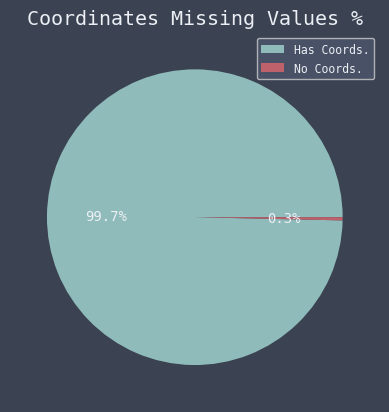

In [7]:
has_coords_counts = fe_df["Has Coordinates"].value_counts(normalize=True)

plt.pie(has_coords_counts, autopct="%1.1f%%", textprops=dict(size=10))
plt.title("Coordinates Missing Values %")
plt.legend(["Has Coords.", "No Coords."], fontsize="x-small", loc="best")
plt.show()

Does Val Lag 1 Day contain many NaN values?

In [8]:
fe_df.isna().mean() * 100

Country Code         0.000000
City                 0.000000
Location             0.000000
Pollutant            0.000000
Source Name          0.000000
Unit                 0.000000
Country Label        0.000000
Val Lag 1 Day       72.633768
Year                 0.000000
Month                0.000000
Day                  0.000000
Month Sin            0.000000
Month Cos            0.000000
Latitude             0.345327
Longitude            0.345327
Has Coordinates      0.000000
Has City             0.000000
Pollutant Danger     0.000000
Value                0.000000
dtype: float64

### Target Variable Analysis

Is the target (Value) normally distributed? Is it right-skewed?

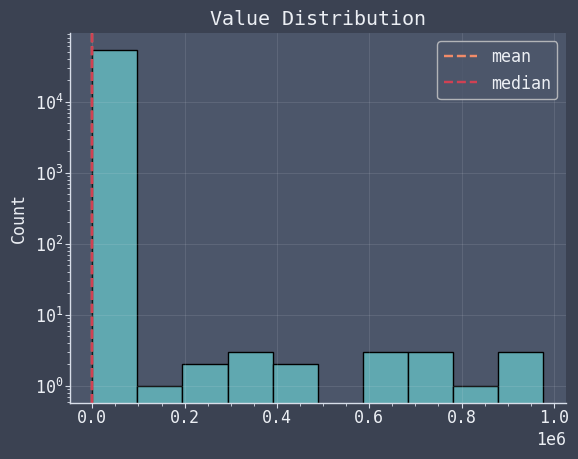

In [9]:
value_stats = fe_df.Value.agg(["mean", "median", "skew"]).round(2)

plt.hist(fe_df.Value, log=True, color="#60a8b0", edgecolor="black")
plt.title("Value Distribution")
plt.ylabel("Count")
plt.axvline(value_stats.iloc[0], color="#f18b69", linestyle="--", label="mean")
plt.axvline(value_stats.iloc[1], color="#d04153", linestyle="--", label="median")
plt.legend()
plt.show()

### Numerical Features Analysis

In [10]:
# let's see the numerical features
fe_df.select_dtypes(include="number").columns

Index(['Val Lag 1 Day', 'Year', 'Month', 'Day', 'Month Sin', 'Month Cos',
       'Latitude', 'Longitude', 'Has Coordinates', 'Has City', 'Value'],
      dtype='str')

Are pollutant levels geographically clustered?

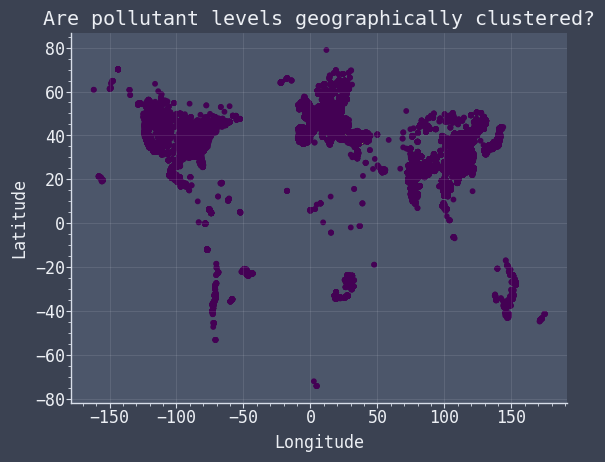

In [11]:
plt.scatter(fe_df.Longitude, fe_df.Latitude, c=fe_df.Value, s=10)
plt.title("Are pollutant levels geographically clustered?")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

How many measures have a city?

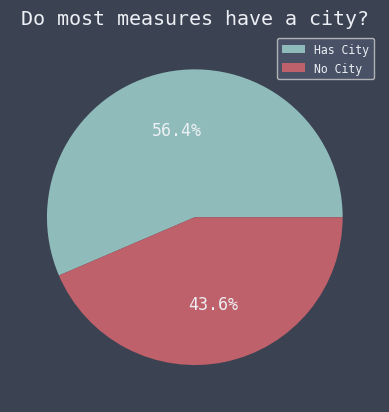

In [12]:
city_counts = fe_df["Has City"].value_counts(normalize=True)

plt.pie(city_counts, autopct="%1.1f%%")
plt.title("Do most measures have a city?")
plt.legend(["Has City", "No City"], fontsize="x-small")
plt.show()

### Categorical Features Analysis

What is the average concentration level per pollutant?

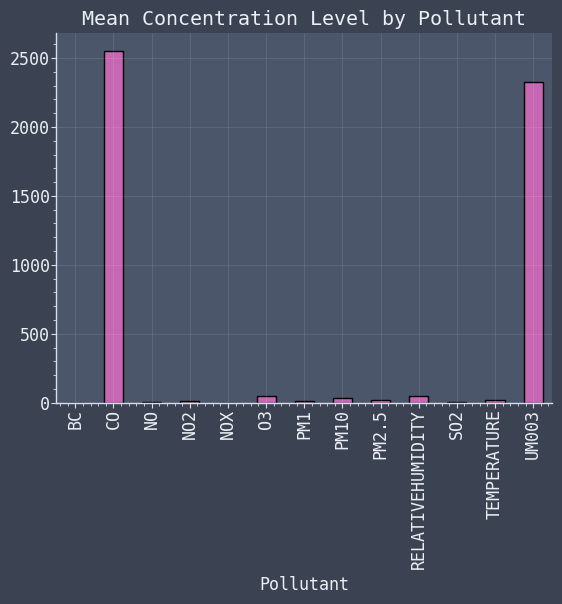

In [13]:
mean_concentrantion_level = fe_df.groupby("Pollutant").Value.mean().round(2)
mean_concentrantion_level.plot(kind="bar", title="Mean Concentration Level by Pollutant", color="#c766b2", edgecolor="black")
plt.show()

Are more pollutants recorded in a certain country vs. the other ones?

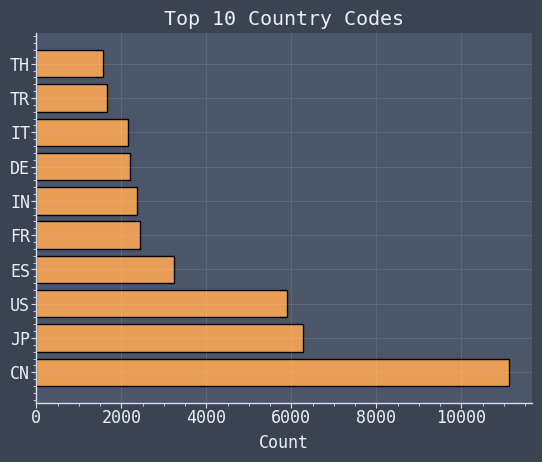

In [14]:
country_code_counts = fe_df["Country Code"].value_counts().nlargest(10)

plt.barh(country_code_counts.index, country_code_counts.values, color="#e89e56", edgecolor="black")
plt.title("Top 10 Country Codes")
plt.xlabel("Count")
plt.show()

### Feature vs. Target Analysis

Is the previous day value correlated to the actual one?

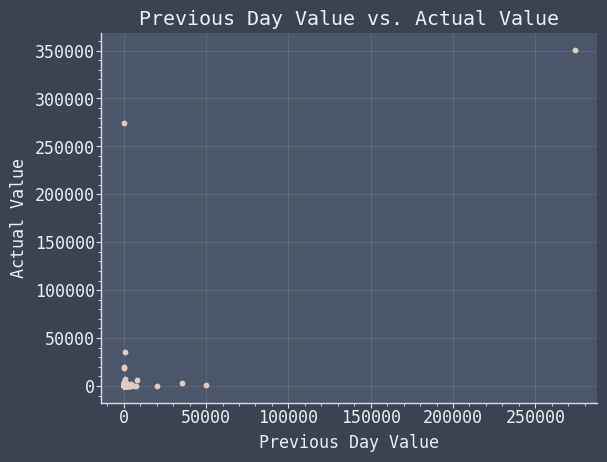

In [15]:
plt.scatter(fe_df["Val Lag 1 Day"].values, fe_df.Value.values, s=10, color="#dfcbbf")
plt.title("Previous Day Value vs. Actual Value")
plt.xlabel("Previous Day Value")
plt.ylabel("Actual Value")
plt.show()

Which countries pollute the most?

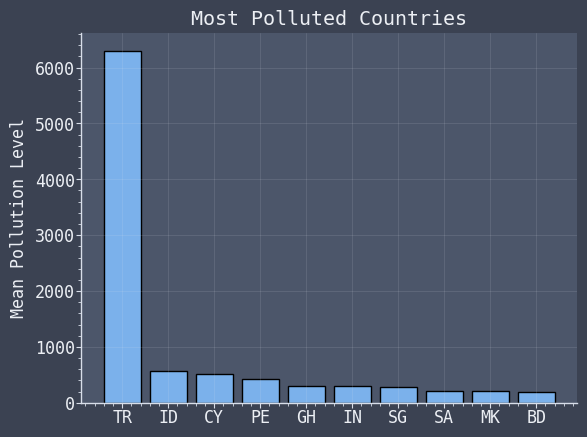

In [16]:
top_countries = fe_df.groupby("Country Code").Value.agg("mean").sort_values(ascending=False).head(10)

plt.bar(top_countries.index, top_countries.values, color="#7bb1eb", edgecolor="black")
plt.title("Most Polluted Countries")
plt.ylabel("Mean Pollution Level")
plt.show()

Are pollution levels lower in some months?

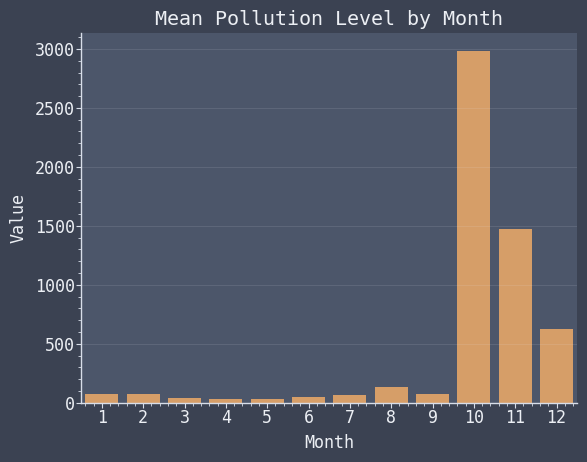

In [17]:
sns.barplot(data=fe_df, x="Month", y="Value", estimator="mean", errorbar=None, color="#e89e56")
plt.title("Mean Pollution Level by Month")
plt.show()

### Correlation Analysis

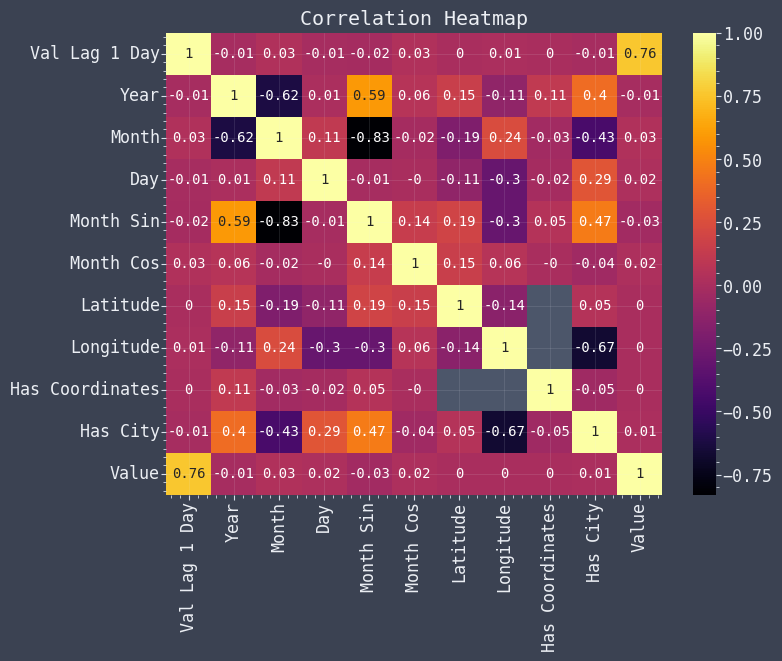

In [18]:
numeric_corrs = fe_df.corr(numeric_only=True, method="pearson").round(2)

plt.figure(figsize=(8, 6))
sns.heatmap(data=numeric_corrs, cmap="inferno", annot=True, annot_kws={"fontsize": 10})
plt.title("Correlation Heatmap")
plt.show()

Which are the features most correlated with Value?

In [19]:
fe_df.corr(numeric_only=True).Value.nlargest(5)

Value            1.000000
Val Lag 1 Day    0.763307
Month            0.031733
Month Cos        0.022437
Day              0.016668
Name: Value, dtype: float64

### Outlier Analysis

Does Value have unusual observations? What is its IQR?

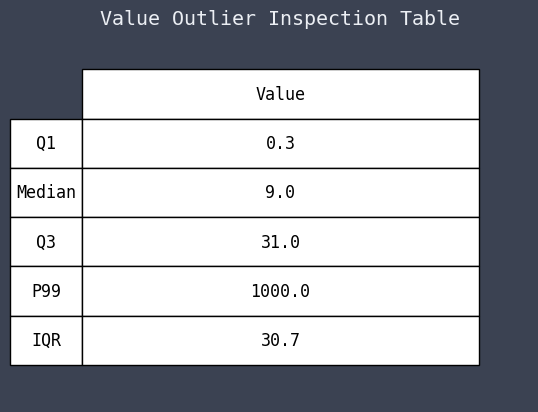

In [20]:
value_stats = {
    "Q1": fe_df.Value.quantile(0.25),
    "Median": fe_df.Value.quantile(0.50),
    "Q3": fe_df.Value.quantile(0.75),
    "P99": fe_df.Value.quantile(0.99),
    "IQR": stats.iqr(fe_df.Value)
}

value_stats_df = pd.DataFrame.from_dict(data=value_stats, orient="index", columns=["Value"])

value_table = plt.table(cellText=value_stats_df.values, cellLoc="center", rowLabels=value_stats_df.index, 
          rowLoc="center", colLabels=value_stats_df.columns, colLoc="center", 
          bbox=(0.1, 0.1, 0.8, 0.8))

for (row, col), cell in value_table.get_celld().items():
    cell.get_text().set_color("black")

plt.axis("off")
plt.title("Value Outlier Inspection Table")
plt.show()

## Exploratory Data Analysis Conclusions

1.	Missing Values Analysis: 0.3% of the dataset is characterized by missing coordinates. 72.6% of observations lack a previous-day pollution measurement, which may reduce the predictive value of the lag feature for many records.
2.	The “Value” distribution isn’t normally distributed. It is right skewed as seen by the long right tail, indicating that some pollutants achieve high pollution levels. 
3.	Numerical Features Analysis: 
-	Monitoring observations are concentrated in the USA, Northern Europe and Eastern Asia, suggesting potential geographic patterns in pollution levels.
-	56.4% of pollutants have a city, meaning that for some measures we don’t have enough city data to know where the pollutant was recorded.
4.	Categorical Features Analysis:
-	UM003 and CO exhibit the highest recorded concentration values in the dataset.
-	Most measures are recorded in China, followed by Japan and USA. Interestingly, this confirms the previous discovery where, according to the data, most pollution is clustered in USA and Eastern China.
5.	Feature vs. Target Analysis:
-	The previous day’s pollution level is highly correlated with the current value, as indicated by the scatter plot. This is important as the feature likely will be one of the most useful ones for machine learning models.
-	The most polluted countries, on average, are Turkey, followed by India and China. 
-	The mean pollution level tends to be the highest in the last months of the year, namely, October, November and December. 
6.	Correlation Analysis:
-	The most correlated feature with Value is the previous day’s value, not surprisingly (0.76). This confirms the strong temporal persistence of pollution measurements and suggests that recent observations are highly informative for predicting future pollution levels.
7.	Outlier Analysis:
-	The Value feature is right skewed as we saw earlier. 
-	The large gap between Q3 (31) and the 99th percentile (1000) indicates the presence of substantial outliers and a heavy right tail. These extreme observations are likely genuine pollution events rather than data-entry errors and should be considered during modeling.